# AI-Driven Forecasting of Medical Inventory Shortages

## Complete Machine Learning + Time Series Notebook

**Goal:** Predict whether an active inventory item will face a stockout before the next replenishment cycle.

**Target column:** `stockout_event`

This notebook includes:

1. Dataset loading and validation  
2. Full EDA checks  
3. Missing value and duplicate handling  
4. Feature engineering  
5. Classification model training  
6. Accuracy comparison for every model  
7. Precision, recall, F1, ROC-AUC, PR-AUC comparison  
8. Class imbalance handling  
9. Cross-validation  
10. Hyperparameter tuning  
11. Best model selection  
12. Confusion matrix and classification report  
13. Feature importance  
14. SHAP explainability if installed  
15. Time series trend analysis  
16. Lag and rolling features  
17. ARIMA / SARIMA forecasting if installed  
18. Prophet forecasting if installed  
19. Supervised time-series forecasting using ML  
20. Model saving for production

## What Was Missing in the Previous Notebook

The earlier notebook mostly covered basic EDA. For a complete ML project, these parts were missing:

- Proper train-test split
- Date-based split for time-aware validation
- Complete preprocessing pipeline
- Numerical and categorical imputation
- One-hot encoding
- Feature engineering
- Multiple ML models
- Model comparison table
- Accuracy ranking
- Recall / F1 / ROC-AUC / PR-AUC ranking
- Class imbalance handling
- Cross-validation
- Hyperparameter tuning
- Threshold tuning
- Confusion matrix
- Classification report
- Feature importance
- SHAP explainability
- Time series trend analysis
- Lag features
- Rolling-window features
- ARIMA / SARIMA section
- Prophet section
- ML-based forecasting section
- Best model saving
- Production inference function

In [1]:
# Optional installation cell
# Run this only if packages are missing in your environment.

#!pip install pandas numpy matplotlib seaborn scikit-learn joblib
#!pip install xgboost lightgbm catboost imbalanced-learn statsmodels
#!pip install prophet shap optuna

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [3]:
# Optional model libraries
optional_models_available = {}

try:
    from xgboost import XGBClassifier
    optional_models_available['xgboost'] = True
except Exception as e:
    optional_models_available['xgboost'] = False
    print('XGBoost not available:', e)

try:
    from lightgbm import LGBMClassifier
    optional_models_available['lightgbm'] = True
except Exception as e:
    optional_models_available['lightgbm'] = False
    print('LightGBM not available:', e)

try:
    from catboost import CatBoostClassifier
    optional_models_available['catboost'] = True
except Exception as e:
    optional_models_available['catboost'] = False
    print('CatBoost not available:', e)

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    optional_models_available['imblearn'] = True
except Exception as e:
    optional_models_available['imblearn'] = False
    print('imbalanced-learn not available:', e)

optional_models_available

{'xgboost': True, 'lightgbm': True, 'catboost': True, 'imblearn': True}

In [4]:
# Load dataset
# Keep your CSV file in the same folder as this notebook.

DATA_PATH = 'healthcare_supply_chain_01.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Please place healthcare_supply_chain_01.csv in the notebook folder."
    )

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()

Shape: (89088, 36)


,record_id,snapshot_date,facility_id,facility_type,department,item_id,item_category,item_subcategory,criticality_level,unit_of_measure,shelf_life_days,avg_daily_usage_last_30d,avg_daily_usage_last_90d,usage_cv_last_90d,demand_trend,seasonal_demand_factor,recent_usage_spike,current_stock_on_hand,safety_stock_level,days_of_supply_on_hand,stock_as_pct_of_safety_level,reorder_point_days,days_until_next_scheduled_order,primary_vendor_id,vendor_reliability_score,contracted_lead_time_days,actual_avg_lead_time_last_6m,lead_time_variability_days,active_po_in_transit,backorder_frequency_last_12m,sole_source_item,substitution_available,facility_census_pct,pandemic_or_surge_flag,days_since_last_stockout,stockout_event
0,SC00000001,2022-06-02,FAC0051,Acute Care Hospital,Emergency Department,ITEM00406,Medications,Biologics & Specialty,High,Each,651,12.1,11.7,0.260,Increasing,1.10,Yes,168,229,13.9,73.4,10.7,14,VND035,3.4,7,8.0,0.7,No,2,No,No,68.5,No,240,0
1,SC00000002,2024-07-16,FAC0116,Long-Term Care,Operating Room,ITEM00106,Medications,IV Medications,Medium,Case,80,10.0,8.2,0.412,Increasing,1.09,No,24,132,2.4,18.2,12.1,14,VND059,3.2,7,8.7,2.4,Yes,1,No,No,31.7,No,276,0
2,SC00000003,2024-08-22,FAC0198,Specialty Hospital,Emergency Department,ITEM00281,Surgical Supplies,Sponges & Gauze,High,Box,884,19.4,17.3,0.215,Increasing,1.25,No,772,630,39.8,122.5,18.1,28,VND023,2.5,12,15.7,0.4,No,1,No,No,72.2,No,74,0
3,SC00000004,2021-11-02,FAC0148,Acute Care Hospital,Operating Room,ITEM00425,Medications,Oral Medications,High,Case,507,26.0,29.7,0.171,Stable,1.10,No,315,416,12.1,75.7,7.0,14,VND081,3.2,3,3.6,1.4,No,2,No,No,39.8,No,87,0
4,SC00000005,2022-04-26,FAC0059,Long-Term Care,Emergency Department,ITEM00029,Implants & Prosthetics,Cardiovascular Implants,High,Each,1670,5.5,5.3,0.284,Decreasing,0.83,No,357,278,64.9,128.4,31.6,21,VND015,3.4,27,27.6,2.0,Yes,2,Yes,No,63.4,Yes,725,0


In [5]:
# Basic schema validation
TARGET = 'stockout_event'
DATE_COL = 'snapshot_date'
ID_COLS = ['record_id']

required_cols = [TARGET, DATE_COL]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

# Convert date
if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

print('Columns:', len(df.columns))
print(df.dtypes)

Columns: 36
record_id                                     str
snapshot_date                      datetime64[us]
facility_id                                   str
facility_type                                 str
department                                    str
item_id                                       str
item_category                                 str
item_subcategory                              str
criticality_level                             str
unit_of_measure                               str
shelf_life_days                             int64
avg_daily_usage_last_30d                  float64
avg_daily_usage_last_90d                  float64
usage_cv_last_90d                         float64
demand_trend                                  str
seasonal_demand_factor                    float64
recent_usage_spike                            str
current_stock_on_hand                       int64
safety_stock_level                          int64
days_of_supply_on_hand                

# 1. EDA and Data Quality Checks

In [6]:
# Dataset overview
summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isnull().sum().values,
    'missing_pct': (df.isnull().mean() * 100).round(2).values,
    'unique_count': df.nunique(dropna=False).values
})
summary.sort_values('missing_pct', ascending=False)

,column,dtype,missing_count,missing_pct,unique_count
0,record_id,str,0,0.0,89088
1,snapshot_date,datetime64[us],0,0.0,1042
2,facility_id,str,0,0.0,194
3,facility_type,str,0,0.0,5
4,department,str,0,0.0,13
5,item_id,str,0,0.0,442
6,item_category,str,0,0.0,7
7,item_subcategory,str,0,0.0,28
8,criticality_level,str,0,0.0,4
9,unit_of_measure,str,0,0.0,8


In [7]:
# Duplicate check
print('Duplicate rows:', df.duplicated().sum())

# Target distribution
print(df[TARGET].value_counts(dropna=False))
print('Target percentage:')
print((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2))

Duplicate rows: 0
stockout_event
0    69612
1    19476
Name: count, dtype: int64
Target percentage:
stockout_event
0    78.14
1    21.86
Name: proportion, dtype: float64


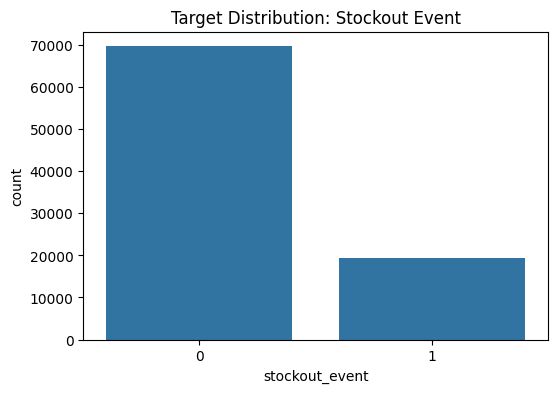

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=TARGET)
plt.title('Target Distribution: Stockout Event')
plt.show()

In [9]:
# Numerical and categorical columns
categorical_cols_raw = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols_raw = df.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()

print('Categorical columns:', categorical_cols_raw)
print('Numerical columns:', numerical_cols_raw)

Categorical columns: ['record_id', 'facility_id', 'facility_type', 'department', 'item_id', 'item_category', 'item_subcategory', 'criticality_level', 'unit_of_measure', 'demand_trend', 'recent_usage_spike', 'primary_vendor_id', 'active_po_in_transit', 'sole_source_item', 'substitution_available', 'pandemic_or_surge_flag']
Numerical columns: ['shelf_life_days', 'avg_daily_usage_last_30d', 'avg_daily_usage_last_90d', 'usage_cv_last_90d', 'seasonal_demand_factor', 'current_stock_on_hand', 'safety_stock_level', 'days_of_supply_on_hand', 'stock_as_pct_of_safety_level', 'reorder_point_days', 'days_until_next_scheduled_order', 'vendor_reliability_score', 'contracted_lead_time_days', 'actual_avg_lead_time_last_6m', 'lead_time_variability_days', 'backorder_frequency_last_12m', 'facility_census_pct', 'days_since_last_stockout', 'stockout_event']


In [10]:
# Unique values for every column
unique_values = {}
for col in df.columns:
    vals = df[col].dropna().unique()
    unique_values[col] = vals[:50]
    print(f'Column: {col}')
    print(f'Unique count: {df[col].nunique(dropna=False)}')
    print(vals[:20])

Column: record_id
Unique count: 89088
<StringArray>
['SC00000001', 'SC00000002', 'SC00000003', 'SC00000004', 'SC00000005',
 'SC00000006', 'SC00000007', 'SC00000008', 'SC00000009', 'SC00000010',
 'SC00000011', 'SC00000012', 'SC00000013', 'SC00000014', 'SC00000015',
 'SC00000016', 'SC00000017', 'SC00000018', 'SC00000019', 'SC00000020']
Length: 20, dtype: str
Column: snapshot_date
Unique count: 1042
<DatetimeArray>
['2022-06-02 00:00:00', '2024-07-16 00:00:00', '2024-08-22 00:00:00',
 '2021-11-02 00:00:00', '2022-04-26 00:00:00', '2021-02-18 00:00:00',
 '2022-03-30 00:00:00', '2022-07-04 00:00:00', '2024-03-28 00:00:00',
 '2024-09-11 00:00:00', '2023-08-02 00:00:00', '2023-12-07 00:00:00',
 '2024-03-19 00:00:00', '2024-10-29 00:00:00', '2023-04-10 00:00:00',
 '2021-04-23 00:00:00', '2022-10-25 00:00:00', '2022-10-18 00:00:00',
 '2024-12-16 00:00:00', '2022-06-23 00:00:00']
Length: 20, dtype: datetime64[us]
Column: facility_id
Unique count: 194
<StringArray>
['FAC0051', 'FAC0116', 'FAC0198

In [11]:
# Numeric summary
num_cols_for_summary = [c for c in numerical_cols_raw if c != TARGET]
df[num_cols_for_summary].describe().T

,count,mean,std,min,25%,50%,75%,max
shelf_life_days,89088.0,619.627144,470.927225,30.00,254.000,498.000,928.00,2837.000
avg_daily_usage_last_30d,89088.0,43.940825,45.906133,0.30,16.300,30.000,55.20,811.000
avg_daily_usage_last_90d,89088.0,44.667487,47.964303,0.30,16.100,30.000,55.80,818.700
usage_cv_last_90d,89088.0,0.250034,0.143729,0.02,0.139,0.229,0.34,0.897
seasonal_demand_factor,89088.0,1.014826,0.121722,0.65,0.930,1.010,1.10,1.510
current_stock_on_hand,89088.0,961.112002,1736.359108,0.00,125.000,383.000,1070.00,82108.000
safety_stock_level,89088.0,865.452104,1086.172225,2.00,260.000,529.000,1054.25,25362.000
days_of_supply_on_hand,89088.0,21.824967,22.088913,0.50,5.700,13.700,32.00,120.000
stock_as_pct_of_safety_level,89088.0,142.958460,178.091275,0.00,28.300,76.700,186.40,999.900
reorder_point_days,89088.0,13.253209,7.355433,2.50,7.700,11.200,16.70,48.700


In [12]:
# Categorical summary
cat_cols_for_summary = [c for c in categorical_cols_raw if c not in [TARGET]]
if len(cat_cols_for_summary) > 0:
    display(df[cat_cols_for_summary].describe().T)

,count,unique,top,freq
record_id,89088,89088,SC00000001,1
facility_id,89088,194,FAC0024,4331
facility_type,89088,5,Acute Care Hospital,40846
department,89088,13,Operating Room,20997
item_id,89088,442,ITEM00308,2583
item_category,89088,7,Surgical Supplies,20456
item_subcategory,89088,28,Drapes & Gowns,6182
criticality_level,89088,4,High,34386
unit_of_measure,89088,8,Each,24049
demand_trend,89088,3,Stable,53345


In [13]:
# Missing value plot
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    plt.figure(figsize=(12,5))
    missing_pct.plot(kind='bar')
    plt.title('Missing Values Percentage')
    plt.ylabel('Missing %')
    plt.show()
else:
    print('No missing values found.')

No missing values found.


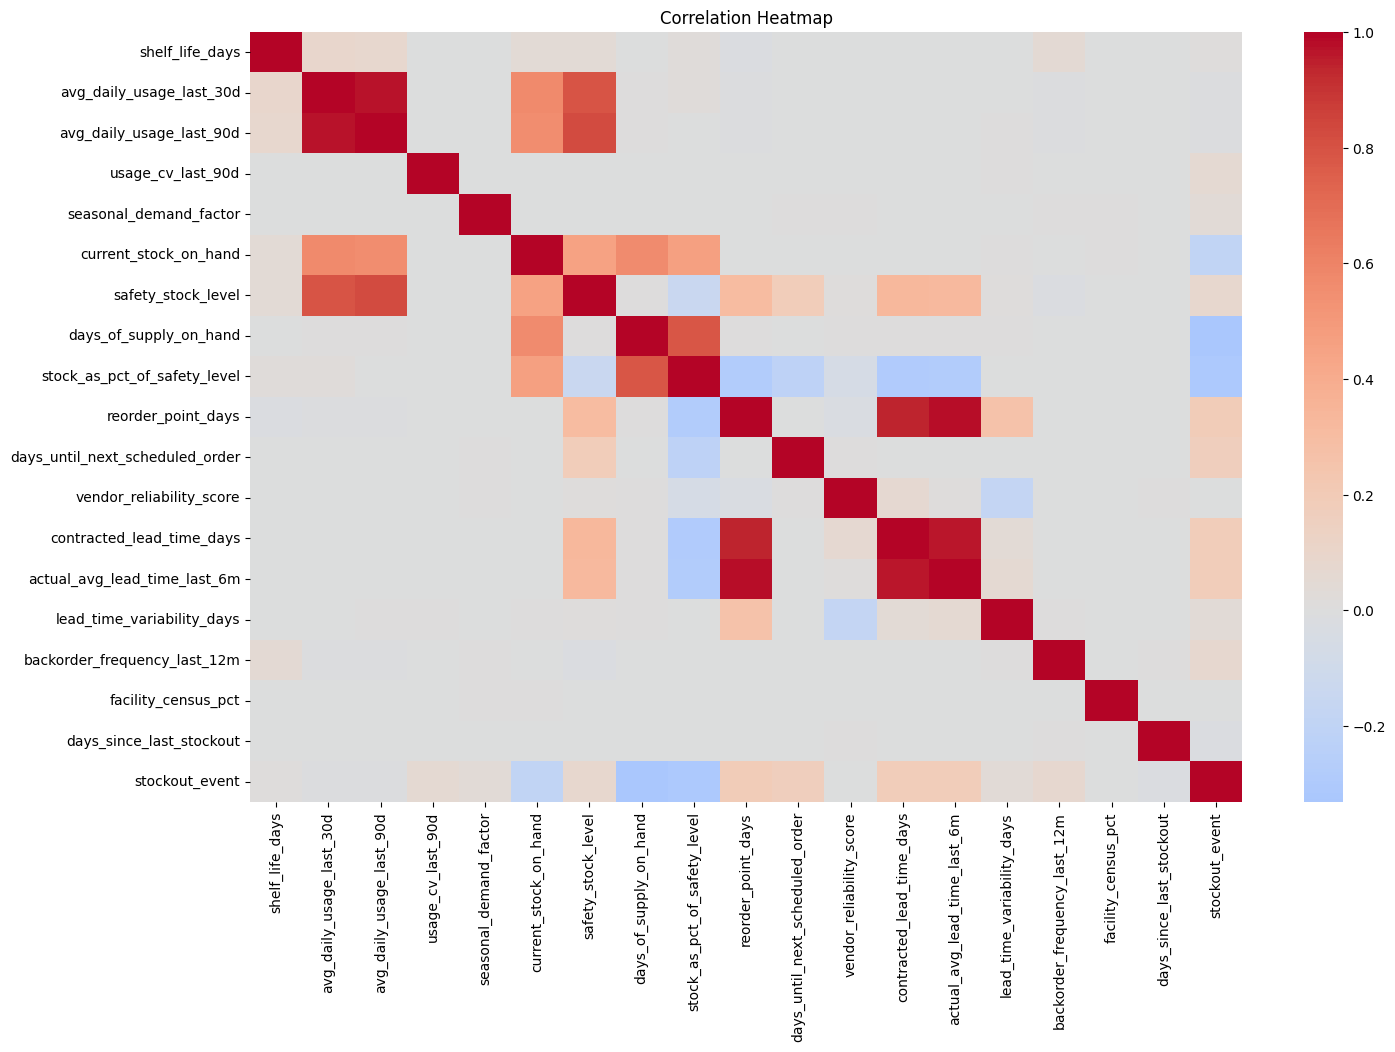

In [14]:
# Correlation heatmap for numerical columns
corr_cols = [c for c in numerical_cols_raw if c != TARGET]
if len(corr_cols) > 1:
    plt.figure(figsize=(16,10))
    sns.heatmap(df[corr_cols + [TARGET]].corr(numeric_only=True), cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.show()

# 2. Feature Engineering

This section creates business-relevant features for inventory shortage prediction.

In [15]:

# =========================
# ROBUST FEATURE ENGINEERING - FIXED VERSION
# =========================

def to_numeric_safe(series):
    """
    Converts numeric-looking values to numbers.
    Handles Yes/No, True/False, percentages, commas, and blanks.
    """
    if pd.api.types.is_numeric_dtype(series):
        return series

    s = series.astype(str).str.strip().str.lower()

    bool_map = {
        'yes': 1, 'y': 1, 'true': 1, 't': 1, '1': 1,
        'no': 0, 'n': 0, 'false': 0, 'f': 0, '0': 0
    }

    mapped = s.map(bool_map)

    cleaned = (
        s.str.replace('%', '', regex=False)
         .str.replace(',', '', regex=False)
         .replace({'nan': np.nan, 'none': np.nan, 'null': np.nan, '': np.nan})
    )

    numeric = pd.to_numeric(cleaned, errors='coerce')

    return mapped.where(mapped.notna(), numeric)


def safe_divide(a, b):
    a = pd.to_numeric(a, errors='coerce')
    b = pd.to_numeric(b, errors='coerce')
    return np.where((b == 0) | (b.isna()), 0, a / b)


def create_features(df):
    data = df.copy()

    if 'snapshot_date' in data.columns:
        data['snapshot_date'] = pd.to_datetime(data['snapshot_date'], errors='coerce')
        data['snapshot_year'] = data['snapshot_date'].dt.year
        data['snapshot_month'] = data['snapshot_date'].dt.month
        data['snapshot_day'] = data['snapshot_date'].dt.day
        data['snapshot_dayofweek'] = data['snapshot_date'].dt.dayofweek
        data['snapshot_weekofyear'] = data['snapshot_date'].dt.isocalendar().week.astype('float')
        data['snapshot_quarter'] = data['snapshot_date'].dt.quarter

    expected_numeric_cols = [
        'avg_daily_usage_last_30d',
        'avg_daily_usage_last_90d',
        'usage_cv_last_90d',
        'seasonal_demand_factor',
        'recent_usage_spike',
        'current_stock_on_hand',
        'safety_stock_level',
        'days_of_supply_on_hand',
        'stock_as_pct_of_safety_level',
        'reorder_point_days',
        'days_until_next_scheduled_order',
        'vendor_reliability_score',
        'contracted_lead_time_days',
        'actual_avg_lead_time_last_6m',
        'lead_time_variability_days',
        'active_po_in_transit',
        'backorder_frequency_last_12m',
        'facility_census_pct',
        'pandemic_or_surge_flag',
        'days_since_last_stockout',
        'shelf_life_days'
    ]

    for col in expected_numeric_cols:
        if col in data.columns:
            data[col] = to_numeric_safe(data[col])

    binary_like_cols = [
        'recent_usage_spike',
        'active_po_in_transit',
        'sole_source_item',
        'substitution_available',
        'pandemic_or_surge_flag'
    ]

    for col in binary_like_cols:
        if col in data.columns:
            data[col + '_binary'] = to_numeric_safe(data[col]).fillna(0)

    if {'current_stock_on_hand', 'safety_stock_level'}.issubset(data.columns):
        data['stock_buffer'] = data['current_stock_on_hand'] - data['safety_stock_level']
        data['stock_to_safety_ratio'] = safe_divide(data['current_stock_on_hand'], data['safety_stock_level'])
        data['below_safety_stock_flag'] = (data['current_stock_on_hand'] < data['safety_stock_level']).astype(int)

    if {'current_stock_on_hand', 'avg_daily_usage_last_30d'}.issubset(data.columns):
        data['estimated_days_until_empty'] = safe_divide(data['current_stock_on_hand'], data['avg_daily_usage_last_30d'])

    if {'days_of_supply_on_hand', 'reorder_point_days'}.issubset(data.columns):
        data['reorder_urgency_gap'] = data['days_of_supply_on_hand'] - data['reorder_point_days']
        data['needs_reorder_flag'] = (data['days_of_supply_on_hand'] <= data['reorder_point_days']).astype(int)

    if {'avg_daily_usage_last_30d', 'avg_daily_usage_last_90d'}.issubset(data.columns):
        data['usage_change_30_vs_90'] = data['avg_daily_usage_last_30d'] - data['avg_daily_usage_last_90d']
        data['usage_ratio_30_vs_90'] = safe_divide(data['avg_daily_usage_last_30d'], data['avg_daily_usage_last_90d'])

    if {'recent_usage_spike', 'avg_daily_usage_last_30d'}.issubset(data.columns):
        data['spike_usage_interaction'] = data['recent_usage_spike'] * data['avg_daily_usage_last_30d']

    if {'seasonal_demand_factor', 'avg_daily_usage_last_30d'}.issubset(data.columns):
        data['seasonal_adjusted_usage'] = data['seasonal_demand_factor'] * data['avg_daily_usage_last_30d']

    if {'facility_census_pct', 'avg_daily_usage_last_30d'}.issubset(data.columns):
        data['census_adjusted_usage'] = data['facility_census_pct'] * data['avg_daily_usage_last_30d']

    if 'vendor_reliability_score' in data.columns:
        data['vendor_risk_score'] = 1 - data['vendor_reliability_score']

    if {'actual_avg_lead_time_last_6m', 'contracted_lead_time_days'}.issubset(data.columns):
        data['lead_time_delay'] = data['actual_avg_lead_time_last_6m'] - data['contracted_lead_time_days']

    if {'lead_time_variability_days', 'actual_avg_lead_time_last_6m'}.issubset(data.columns):
        data['lead_time_uncertainty_ratio'] = safe_divide(data['lead_time_variability_days'], data['actual_avg_lead_time_last_6m'])

    if {'vendor_risk_score', 'lead_time_variability_days'}.issubset(data.columns):
        data['supplier_risk_index'] = data['vendor_risk_score'] * data['lead_time_variability_days']

    if 'criticality_level' in data.columns:
        criticality_map = {
            'low': 1,
            'medium': 2,
            'moderate': 2,
            'high': 3,
            'critical': 4
        }
        data['criticality_score'] = (
            data['criticality_level']
            .astype(str)
            .str.strip()
            .str.lower()
            .map(criticality_map)
        )

    risk_cols = [
        'below_safety_stock_flag',
        'needs_reorder_flag',
        'recent_usage_spike_binary',
        'pandemic_or_surge_flag_binary',
        'vendor_risk_score',
        'lead_time_uncertainty_ratio',
        'supplier_risk_index',
        'backorder_frequency_last_12m'
    ]

    available_risk_cols = [col for col in risk_cols if col in data.columns]

    if available_risk_cols:
        risk_matrix = data[available_risk_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
        data['inventory_risk_score'] = risk_matrix.mean(axis=1)

    data = data.replace([np.inf, -np.inf], np.nan)

    return data


featured_df = create_features(df)
print('Original shape:', df.shape)
print('After feature engineering:', featured_df.shape)
display(featured_df.head())


Original shape: (89088, 36)
After feature engineering: (89088, 64)


,record_id,snapshot_date,facility_id,facility_type,department,item_id,item_category,item_subcategory,criticality_level,unit_of_measure,shelf_life_days,avg_daily_usage_last_30d,avg_daily_usage_last_90d,usage_cv_last_90d,demand_trend,seasonal_demand_factor,recent_usage_spike,current_stock_on_hand,safety_stock_level,days_of_supply_on_hand,stock_as_pct_of_safety_level,reorder_point_days,days_until_next_scheduled_order,primary_vendor_id,vendor_reliability_score,contracted_lead_time_days,actual_avg_lead_time_last_6m,lead_time_variability_days,active_po_in_transit,backorder_frequency_last_12m,sole_source_item,substitution_available,facility_census_pct,pandemic_or_surge_flag,days_since_last_stockout,stockout_event,snapshot_year,snapshot_month,snapshot_day,snapshot_dayofweek,snapshot_weekofyear,snapshot_quarter,recent_usage_spike_binary,active_po_in_transit_binary,sole_source_item_binary,substitution_available_binary,pandemic_or_surge_flag_binary,stock_buffer,stock_to_safety_ratio,below_safety_stock_flag,estimated_days_until_empty,reorder_urgency_gap,needs_reorder_flag,usage_change_30_vs_90,usage_ratio_30_vs_90,spike_usage_interaction,seasonal_adjusted_usage,census_adjusted_usage,vendor_risk_score,lead_time_delay,lead_time_uncertainty_ratio,supplier_risk_index,criticality_score,inventory_risk_score
0,SC00000001,2022-06-02,FAC0051,Acute Care Hospital,Emergency Department,ITEM00406,Medications,Biologics & Specialty,High,Each,651,12.1,11.7,0.260,Increasing,1.10,1,168,229,13.9,73.4,10.7,14,VND035,3.4,7,8.0,0.7,0,2,No,No,68.5,0,240,0,2022,6,2,3,22.0,2,1,0,0,0,0,-61,0.733624,1,13.884298,3.2,0,0.4,1.034188,12.1,13.310,828.85,-2.4,1.0,0.087500,-1.68,3,0.000938
1,SC00000002,2024-07-16,FAC0116,Long-Term Care,Operating Room,ITEM00106,Medications,IV Medications,Medium,Case,80,10.0,8.2,0.412,Increasing,1.09,0,24,132,2.4,18.2,12.1,14,VND059,3.2,7,8.7,2.4,1,1,No,No,31.7,0,276,0,2024,7,16,1,29.0,3,0,1,0,0,0,-108,0.181818,1,2.400000,-9.7,1,1.8,1.219512,0.0,10.900,317.00,-2.2,1.7,0.275862,-5.28,2,-0.525517
2,SC00000003,2024-08-22,FAC0198,Specialty Hospital,Emergency Department,ITEM00281,Surgical Supplies,Sponges & Gauze,High,Box,884,19.4,17.3,0.215,Increasing,1.25,0,772,630,39.8,122.5,18.1,28,VND023,2.5,12,15.7,0.4,0,1,No,No,72.2,0,74,0,2024,8,22,3,34.0,3,0,0,0,0,0,142,1.225397,0,39.793814,21.7,0,2.1,1.121387,0.0,24.250,1400.68,-1.5,3.7,0.025478,-0.60,3,-0.134315
3,SC00000004,2021-11-02,FAC0148,Acute Care Hospital,Operating Room,ITEM00425,Medications,Oral Medications,High,Case,507,26.0,29.7,0.171,Stable,1.10,0,315,416,12.1,75.7,7.0,14,VND081,3.2,3,3.6,1.4,0,2,No,No,39.8,0,87,0,2021,11,2,1,44.0,4,0,0,0,0,0,-101,0.757212,1,12.115385,5.1,0,-3.7,0.875421,0.0,28.600,1034.80,-2.2,0.6,0.388889,-3.08,3,-0.236389
4,SC00000005,2022-04-26,FAC0059,Long-Term Care,Emergency Department,ITEM00029,Implants & Prosthetics,Cardiovascular Implants,High,Each,1670,5.5,5.3,0.284,Decreasing,0.83,0,357,278,64.9,128.4,31.6,21,VND015,3.4,27,27.6,2.0,1,2,Yes,No,63.4,1,725,0,2022,4,26,1,17.0,2,0,1,1,0,1,79,1.284173,0,64.909091,33.3,0,0.2,1.037736,0.0,4.565,348.70,-2.4,0.6,0.072464,-4.80,3,-0.515942


# 3. Prepare Data for Machine Learning

Important notes:

- `record_id` is removed because it is only an identifier.
- `snapshot_date` is used to create date features, then removed before model training.
- The target is `stockout_event`.

In [16]:
# Clean target
model_df = featured_df.copy()

# Convert target to numeric if needed
if model_df[TARGET].dtype == 'object':
    model_df[TARGET] = model_df[TARGET].astype(str).str.lower().map({
        'yes': 1, 'true': 1, '1': 1, 'stockout': 1,
        'no': 0, 'false': 0, '0': 0, 'no_stockout': 0
    }).fillna(model_df[TARGET])

model_df[TARGET] = model_df[TARGET].astype(int)

# Drop rows with missing target
model_df = model_df.dropna(subset=[TARGET])

# Columns to drop from features
drop_cols = [TARGET]
for c in ID_COLS + [DATE_COL]:
    if c in model_df.columns:
        drop_cols.append(c)

X = model_df.drop(columns=drop_cols, errors='ignore')
y = model_df[TARGET]

# Remove columns that are completely empty
empty_cols = X.columns[X.isnull().all()].tolist()
X = X.drop(columns=empty_cols)

# Identify columns after feature engineering
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'int32', 'float64', 'float32', 'uint32', 'uint64']).columns.tolist()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Numeric cols:', len(numeric_cols))
print('Categorical cols:', len(categorical_cols))
print('Dropped empty cols:', empty_cols)

Feature matrix shape: (89088, 61)
Target shape: (89088,)
Numeric cols: 49
Categorical cols: 12
Dropped empty cols: []


In [17]:
# Helper for OneHotEncoder compatibility across scikit-learn versions

def make_onehot_encoder(dense=False):
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=not dense)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=not dense)

# Dense preprocessing is used because GaussianNB needs dense input.
# For 9000 rows this is acceptable.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', make_onehot_encoder(dense=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

In [18]:
# Random stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train target distribution:')
print(y_train.value_counts(normalize=True).round(3))
print('Test target distribution:')
print(y_test.value_counts(normalize=True).round(3))

Train shape: (71270, 61)
Test shape: (17818, 61)
Train target distribution:
stockout_event
0    0.781
1    0.219
Name: proportion, dtype: float64
Test target distribution:
stockout_event
0    0.781
1    0.219
Name: proportion, dtype: float64


In [19]:
# Time-based split for validation if snapshot_date exists
# This prevents future information from leaking into the past.

time_split_available = DATE_COL in featured_df.columns and featured_df[DATE_COL].notna().sum() > 0

if time_split_available:
    time_df = model_df.sort_values(DATE_COL).copy()
    X_time = time_df.drop(columns=drop_cols, errors='ignore')
    y_time = time_df[TARGET]

    split_idx = int(len(time_df) * 0.80)
    X_train_time = X_time.iloc[:split_idx]
    X_test_time = X_time.iloc[split_idx:]
    y_train_time = y_time.iloc[:split_idx]
    y_test_time = y_time.iloc[split_idx:]

    print('Time-based train shape:', X_train_time.shape)
    print('Time-based test shape:', X_test_time.shape)
    print('Train date range:', time_df[DATE_COL].iloc[:split_idx].min(), 'to', time_df[DATE_COL].iloc[:split_idx].max())
    print('Test date range:', time_df[DATE_COL].iloc[split_idx:].min(), 'to', time_df[DATE_COL].iloc[split_idx:].max())
else:
    print('Time split not available.')

Time-based train shape: (71270, 61)
Time-based test shape: (17818, 61)
Train date range: 2021-01-04 00:00:00 to 2024-03-14 00:00:00
Test date range: 2024-03-14 00:00:00 to 2024-12-31 00:00:00


# 4. Train Every Classification Model

This section trains many ML models and compares performance.

For this business problem, do not look only at accuracy. Also check:

- Recall: how many actual stockouts were detected
- Precision: how many predicted stockouts were correct
- F1 score: balance between precision and recall
- ROC-AUC: ranking performance
- PR-AUC: very useful for imbalanced stockout data

In [20]:
# Model list
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
    #'SVM': SVC(probability=True, class_weight='balanced', random_state=RANDOM_STATE)
}

if optional_models_available.get('xgboost'):
    models['XGBoost'] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

if optional_models_available.get('lightgbm'):
    models['LightGBM'] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    )

if optional_models_available.get('catboost'):
    models['CatBoost'] = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=RANDOM_STATE,
        auto_class_weights='Balanced'
    )

print('Models to train:', list(models.keys()))

Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost', 'Hist Gradient Boosting', 'KNN', 'Naive Bayes', 'XGBoost', 'LightGBM', 'CatBoost']


In [21]:
def evaluate_classifier(model_name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
    elif hasattr(pipeline, 'decision_function'):
        scores = pipeline.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_proba = y_pred

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'PR_AUC': average_precision_score(y_test, y_proba)
    }

In [22]:
trained_pipelines = {}
results = []

for name, model in models.items():
    print(f'Training: {name}')
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f'Evaluating: {name}')
    results.append(evaluate_classifier(name, pipe, X_test, y_test))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df

Training: Logistic Regression
Evaluating: Logistic Regression
Training: Decision Tree
Evaluating: Decision Tree
Training: Random Forest
Evaluating: Random Forest
Training: Extra Trees
Evaluating: Extra Trees
Training: Gradient Boosting
Evaluating: Gradient Boosting
Training: AdaBoost
Evaluating: AdaBoost
Training: Hist Gradient Boosting
Evaluating: Hist Gradient Boosting
Training: KNN
Evaluating: KNN
Training: Naive Bayes
Evaluating: Naive Bayes
Training: XGBoost
Evaluating: XGBoost
Training: LightGBM
[LightGBM] [Info] Number of positive: 15581, number of negative: 55689
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033673 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8125
[LightGBM] [Info] Number of data points in the train set: 71270, number of used features: 711
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Gradient Boosting,0.827366,0.685666,0.659898,0.433890,0.523544,0.867077,0.633648
1,XGBoost,0.826860,0.691630,0.649667,0.451348,0.532647,0.867785,0.632235
2,AdaBoost,0.826748,0.683144,0.659937,0.427985,0.519234,0.867264,0.630120
3,Hist Gradient Boosting,0.825738,0.691836,0.643846,0.453915,0.532450,0.866841,0.631838
4,Random Forest,0.819172,0.652593,0.659857,0.356611,0.463000,0.859083,0.604051
5,Extra Trees,0.819059,0.660102,0.647732,0.377664,0.477133,0.856472,0.603682
6,KNN,0.790212,0.622320,0.533164,0.324005,0.403066,0.780307,0.450937
7,LightGBM,0.762207,0.788114,0.475000,0.834146,0.605310,0.866783,0.629849
8,Decision Tree,0.761309,0.655972,0.455362,0.468806,0.461986,0.655972,0.329595
9,CatBoost,0.757492,0.792586,0.469941,0.854942,0.606502,0.870162,0.638833


In [23]:
# Best model by Accuracy
best_by_accuracy = results_df.sort_values('Accuracy', ascending=False).iloc[0]
print('Best model by Accuracy')
print(best_by_accuracy)

# Best model by F1
best_by_f1 = results_df.sort_values('F1', ascending=False).iloc[0]
print('Best model by F1')
print(best_by_f1)

# Best model by PR-AUC, preferred for imbalanced classification
best_by_pr_auc = results_df.sort_values('PR_AUC', ascending=False).iloc[0]
print('Best model by PR-AUC')
print(best_by_pr_auc)

Best model by Accuracy
Model                Gradient Boosting
Accuracy                      0.827366
Balanced_Accuracy             0.685666
Precision                     0.659898
Recall                         0.43389
F1                            0.523544
ROC_AUC                       0.867077
PR_AUC                        0.633648
Name: 0, dtype: object
Best model by F1
Model                CatBoost
Accuracy             0.757492
Balanced_Accuracy    0.792586
Precision            0.469941
Recall               0.854942
F1                   0.606502
ROC_AUC              0.870162
PR_AUC               0.638833
Name: 9, dtype: object
Best model by PR-AUC
Model                CatBoost
Accuracy             0.757492
Balanced_Accuracy    0.792586
Precision            0.469941
Recall               0.854942
F1                   0.606502
ROC_AUC              0.870162
PR_AUC               0.638833
Name: 9, dtype: object


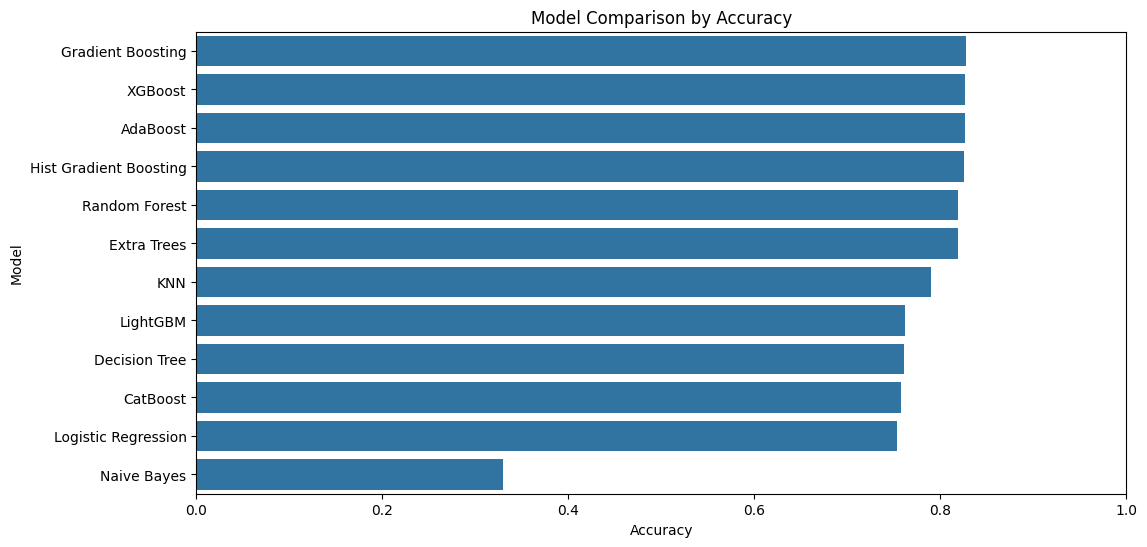

In [24]:
# Visual comparison by Accuracy
plt.figure(figsize=(12,6))
sns.barplot(data=results_df.sort_values('Accuracy', ascending=False), x='Accuracy', y='Model')
plt.title('Model Comparison by Accuracy')
plt.xlim(0, 1)
plt.show()

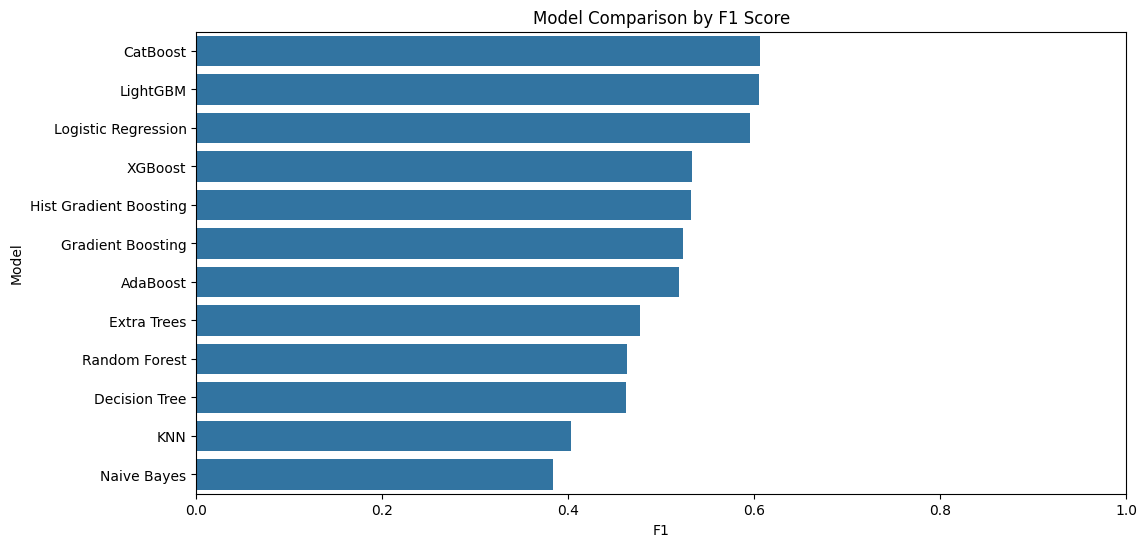

In [25]:
# Visual comparison by F1
plt.figure(figsize=(12,6))
sns.barplot(data=results_df.sort_values('F1', ascending=False), x='F1', y='Model')
plt.title('Model Comparison by F1 Score')
plt.xlim(0, 1)
plt.show()

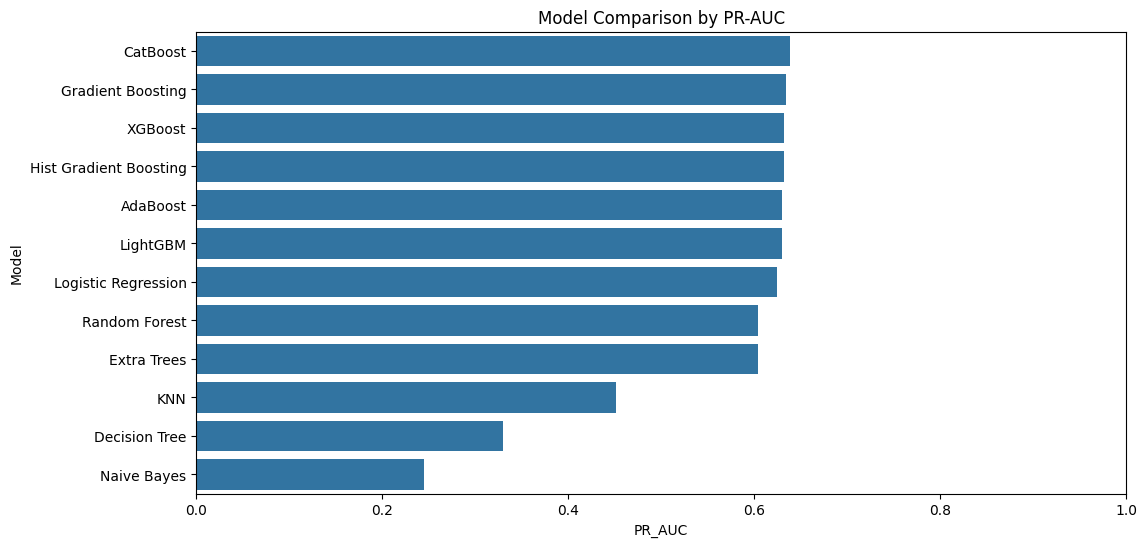

In [26]:
# Visual comparison by PR-AUC
plt.figure(figsize=(12,6))
sns.barplot(data=results_df.sort_values('PR_AUC', ascending=False), x='PR_AUC', y='Model')
plt.title('Model Comparison by PR-AUC')
plt.xlim(0, 1)
plt.show()

# 5. Confusion Matrix and Classification Report for Best Model

Selected best model: CatBoost
Selection metric: PR_AUC
              precision    recall  f1-score   support

           0       0.95      0.73      0.82     13923
           1       0.47      0.85      0.61      3895

    accuracy                           0.76     17818
   macro avg       0.71      0.79      0.72     17818
weighted avg       0.84      0.76      0.78     17818



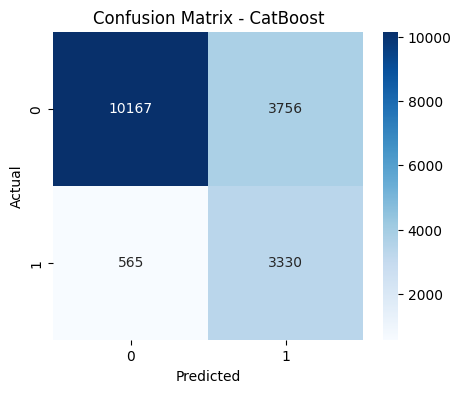

In [27]:
BEST_SELECTION_METRIC = 'PR_AUC'  # Change to 'Accuracy' if your requirement is strictly accuracy.
best_model_name = results_df.sort_values(BEST_SELECTION_METRIC, ascending=False).iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]

print('Selected best model:', best_model_name)
print('Selection metric:', BEST_SELECTION_METRIC)

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

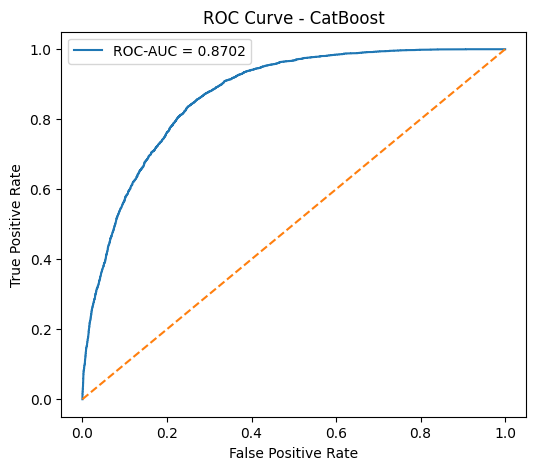

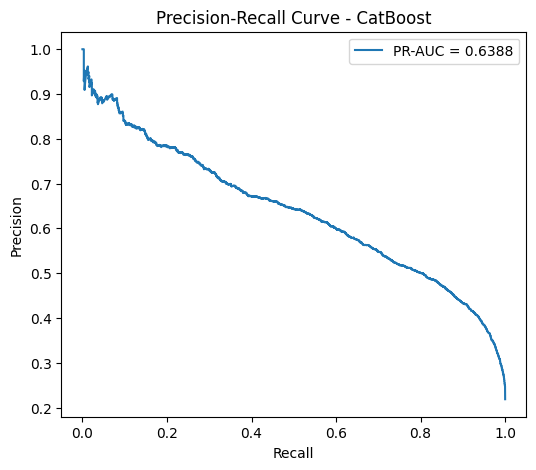

In [28]:
# ROC curve and Precision-Recall curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_proba_best):.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR-AUC = {average_precision_score(y_test, y_proba_best):.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model_name}')
plt.legend()
plt.show()

# 6. Threshold Tuning

For stockout prediction, recall is often more important than accuracy because missing a stockout is costly.
This section finds the best threshold for F1 score.

In [29]:
thresholds = np.arange(0.05, 0.96, 0.01)
threshold_rows = []

for threshold in thresholds:
    pred_t = (y_proba_best >= threshold).astype(int)
    threshold_rows.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, pred_t),
        'Precision': precision_score(y_test, pred_t, zero_division=0),
        'Recall': recall_score(y_test, pred_t, zero_division=0),
        'F1': f1_score(y_test, pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values('F1', ascending=False).iloc[0]
print('Best threshold by F1:')
print(best_threshold_row)
threshold_df.sort_values('F1', ascending=False).head(10)

Best threshold by F1:
Threshold    0.580000
Accuracy     0.788472
Precision    0.510631
Recall       0.776893
F1           0.616231
Name: 53, dtype: float64


,Threshold,Accuracy,Precision,Recall,F1
53,0.58,0.788472,0.510631,0.776893,0.616231
51,0.56,0.782243,0.501208,0.799230,0.616070
52,0.57,0.785049,0.505352,0.787933,0.615770
59,0.64,0.809911,0.551731,0.695507,0.615332
54,0.59,0.791391,0.515435,0.763030,0.615257
58,0.63,0.806544,0.544251,0.707317,0.615161
50,0.55,0.778202,0.495525,0.810270,0.614965
57,0.62,0.802335,0.535585,0.720668,0.614492
60,0.65,0.812381,0.557862,0.683184,0.614195
55,0.60,0.794085,0.520164,0.748395,0.613749


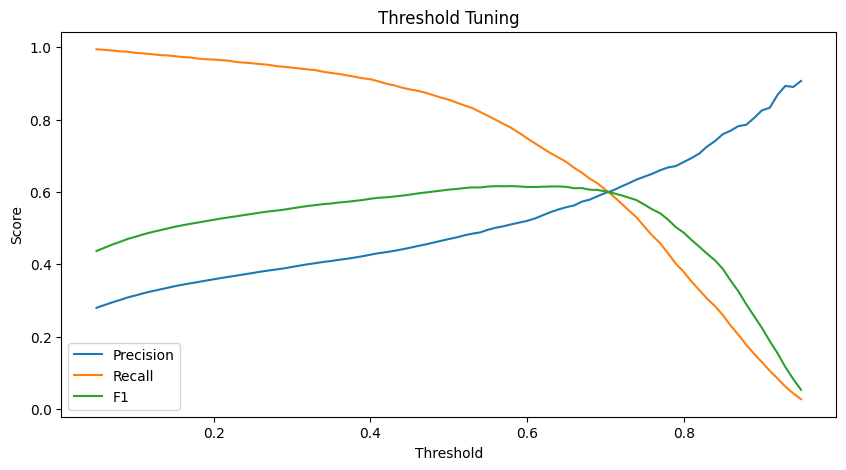

In [30]:
plt.figure(figsize=(10,5))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning')
plt.legend()
plt.show()

# 7. Cross-Validation

Cross-validation gives a more stable estimate than a single train-test split.

In [31]:
cv_models = {}
for model_name in results_df.sort_values('PR_AUC', ascending=False)['Model'].head(5):
    cv_models[model_name] = models[model_name]

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision'
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in cv_models.items():
    print(f'Cross-validating: {name}')
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV_Accuracy_Mean': scores['test_accuracy'].mean(),
        'CV_Accuracy_Std': scores['test_accuracy'].std(),
        'CV_F1_Mean': scores['test_f1'].mean(),
        'CV_Recall_Mean': scores['test_recall'].mean(),
        'CV_ROC_AUC_Mean': scores['test_roc_auc'].mean(),
        'CV_PR_AUC_Mean': scores['test_average_precision'].mean()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_PR_AUC_Mean', ascending=False)
cv_results_df

Cross-validating: CatBoost
Cross-validating: Gradient Boosting
Cross-validating: XGBoost
Cross-validating: Hist Gradient Boosting
Cross-validating: AdaBoost


,Model,CV_Accuracy_Mean,CV_Accuracy_Std,CV_F1_Mean,CV_Recall_Mean,CV_ROC_AUC_Mean,CV_PR_AUC_Mean
0,CatBoost,0.752469,0.001171,0.599317,0.846786,0.865920,0.629736
1,Gradient Boosting,0.827070,0.000895,0.526693,0.440131,0.864104,0.627665
2,XGBoost,0.825745,0.001019,0.530249,0.449887,0.864664,0.624690
3,Hist Gradient Boosting,0.825813,0.000647,0.533791,0.456151,0.863442,0.621237
4,AdaBoost,0.825027,0.000977,0.519165,0.432224,0.861888,0.621030


# 8. Optional SMOTE Training

SMOTE creates synthetic minority-class examples. Use it only on the training set inside a pipeline to avoid data leakage.

In [32]:
if optional_models_available.get('imblearn'):
    smote_models = {
        'SMOTE Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'SMOTE Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'SMOTE Logistic Regression': LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
    }
    if optional_models_available.get('xgboost'):
        smote_models['SMOTE XGBoost'] = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    if optional_models_available.get('lightgbm'):
        smote_models['SMOTE LightGBM'] = LGBMClassifier(random_state=RANDOM_STATE)

    smote_results = []
    smote_pipelines = {}

    for name, model in smote_models.items():
        print(f'Training: {name}')
        pipe = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('model', model)
        ])
        pipe.fit(X_train, y_train)
        smote_pipelines[name] = pipe
        smote_results.append(evaluate_classifier(name, pipe, X_test, y_test))

    smote_results_df = pd.DataFrame(smote_results).sort_values('PR_AUC', ascending=False)
    display(smote_results_df)
else:
    print('imbalanced-learn is not installed. Skipping SMOTE section.')

Training: SMOTE Random Forest
Training: SMOTE Extra Trees
Training: SMOTE Logistic Regression
Training: SMOTE XGBoost
Training: SMOTE LightGBM
[LightGBM] [Info] Number of positive: 55689, number of negative: 55689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.329842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 95197
[LightGBM] [Info] Number of data points in the train set: 111378, number of used features: 739
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
4,SMOTE LightGBM,0.828039,0.708749,0.636723,0.496791,0.558119,0.867785,0.635543
2,SMOTE Logistic Regression,0.757998,0.777192,0.469052,0.811297,0.594432,0.859570,0.619289
3,SMOTE XGBoost,0.823830,0.700785,0.626000,0.482157,0.544743,0.861432,0.617686
0,SMOTE Random Forest,0.817207,0.718090,0.589007,0.541977,0.564514,0.858512,0.601358
1,SMOTE Extra Trees,0.816871,0.700215,0.598504,0.492940,0.540617,0.854150,0.595524


# 9. Hyperparameter Tuning

This tunes the best high-performing model family. You can extend the parameter grids based on runtime.

In [33]:
# Select a tuning candidate. Prefer LightGBM / XGBoost / CatBoost if available; otherwise Random Forest.
preferred_order = ['LightGBM', 'XGBoost', 'CatBoost', 'Random Forest', 'Extra Trees']
tuning_model_name = None
for name in preferred_order:
    if name in models:
        tuning_model_name = name
        break

print('Tuning model:', tuning_model_name)

if tuning_model_name == 'Random Forest':
    tune_model = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None]
    }
elif tuning_model_name == 'Extra Trees':
    tune_model = ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [None, 5, 10, 15, 20],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', None]
    }
elif tuning_model_name == 'XGBoost':
    tune_model = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    param_dist = {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }
elif tuning_model_name == 'LightGBM':
    tune_model = LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE)
    param_dist = {
        'model__n_estimators': [200, 300, 500],
        'model__num_leaves': [15, 31, 63],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    }
elif tuning_model_name == 'CatBoost':
    tune_model = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE, auto_class_weights='Balanced')
    param_dist = {
        'model__iterations': [200, 300, 500],
        'model__depth': [4, 6, 8],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__l2_leaf_reg': [1, 3, 5, 7]
    }

search_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', tune_model)
])

random_search = RandomizedSearchCV(
    search_pipe,
    param_distributions=param_dist,
    n_iter=15,
    scoring='average_precision',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)
print('Best params:', random_search.best_params_)
print('Best CV PR-AUC:', random_search.best_score_)

tuned_best_pipeline = random_search.best_estimator_
tuned_result = evaluate_classifier('Tuned ' + tuning_model_name, tuned_best_pipeline, X_test, y_test)
tuned_result

Tuning model: LightGBM
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Number of positive: 15581, number of negative: 55689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8125
[LightGBM] [Info] Number of data points in the train set: 71270, number of used features: 711
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best params: {'model__subsample': 0.9, 'model__num_leaves': 15, 'model__n_estimators': 200, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}
Best CV PR-AUC: 0.6226235764880935


{'Model': 'Tuned LightGBM',
 'Accuracy': 0.7532270737456505,
 'Balanced_Accuracy': 0.793000665589958,
 'Precision': 0.465283540802213,
 'Recall': 0.8636713735558408,
 'F1': 0.6047640449438202,
 'ROC_AUC': 0.86801402763798,
 'PR_AUC': 0.6321332493352618}

In [34]:
# Add tuned model to leaderboard
final_results_df = pd.concat([
    results_df,
    pd.DataFrame([tuned_result])
], ignore_index=True).sort_values('PR_AUC', ascending=False).reset_index(drop=True)

final_results_df

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,CatBoost,0.757492,0.792586,0.469941,0.854942,0.606502,0.870162,0.638833
1,Gradient Boosting,0.827366,0.685666,0.659898,0.433890,0.523544,0.867077,0.633648
2,XGBoost,0.826860,0.691630,0.649667,0.451348,0.532647,0.867785,0.632235
3,Tuned LightGBM,0.753227,0.793001,0.465284,0.863671,0.604764,0.868014,0.632133
4,Hist Gradient Boosting,0.825738,0.691836,0.643846,0.453915,0.532450,0.866841,0.631838
5,AdaBoost,0.826748,0.683144,0.659937,0.427985,0.519234,0.867264,0.630120
6,LightGBM,0.762207,0.788114,0.475000,0.834146,0.605310,0.866783,0.629849
7,Logistic Regression,0.753788,0.780693,0.464584,0.828498,0.595333,0.862408,0.624610
8,Random Forest,0.819172,0.652593,0.659857,0.356611,0.463000,0.859083,0.604051
9,Extra Trees,0.819059,0.660102,0.647732,0.377664,0.477133,0.856472,0.603682


# 10. Feature Importance

In [35]:
# Get transformed feature names

def get_feature_names(preprocessor):
    feature_names = []
    try:
        num_features = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_cols)
    except Exception:
        num_features = numeric_cols

    try:
        cat_pipeline = preprocessor.named_transformers_['cat']
        cat_features = cat_pipeline.named_steps['onehot'].get_feature_names_out(categorical_cols)
    except Exception:
        cat_features = []

    feature_names = list(num_features) + list(cat_features)
    return feature_names

# Use tuned model if better than original best by PR-AUC
if tuned_result['PR_AUC'] >= final_results_df[final_results_df['Model'] == best_model_name]['PR_AUC'].iloc[0]:
    explain_pipeline = tuned_best_pipeline
    explain_model_name = 'Tuned ' + tuning_model_name
else:
    explain_pipeline = best_pipeline
    explain_model_name = best_model_name

print('Model selected for explanation:', explain_model_name)

Model selected for explanation: CatBoost


,feature,importance
33,stock_to_safety_ratio,15.247720
36,reorder_urgency_gap,11.705981
9,stock_as_pct_of_safety_level,8.533312
11,days_until_next_scheduled_order,5.925753
35,estimated_days_until_empty,5.037954
16,active_po_in_transit,5.004794
8,days_of_supply_on_hand,4.231414
28,active_po_in_transit_binary,4.124712
3,usage_cv_last_90d,3.286727
40,spike_usage_interaction,2.935196


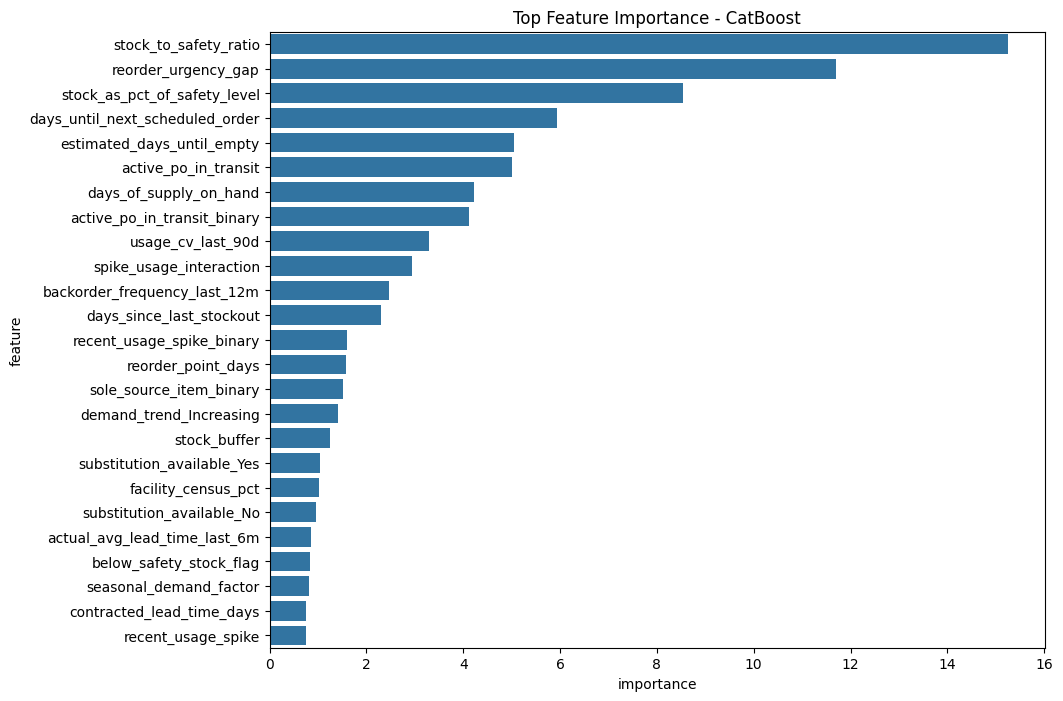

In [36]:
# Built-in feature importance if available
fitted_preprocessor = explain_pipeline.named_steps['preprocessor']
fitted_model = explain_pipeline.named_steps['model']
feature_names = get_feature_names(fitted_preprocessor)

if hasattr(fitted_model, 'feature_importances_'):
    importances = fitted_model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=False)

    display(importance_df.head(30))

    plt.figure(figsize=(10,8))
    sns.barplot(data=importance_df.head(25), x='importance', y='feature')
    plt.title(f'Top Feature Importance - {explain_model_name}')
    plt.show()
else:
    print('This model does not provide built-in feature_importances_. Use permutation importance below.')

In [37]:
# Permutation importance on a sample for speed
sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_test_sample = y_test.loc[X_test_sample.index]

perm = permutation_importance(
    explain_pipeline,
    X_test_sample,
    y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='average_precision'
)

perm_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

perm_df.head(30)

,feature,importance_mean,importance_std
45,stock_to_safety_ratio,0.091610,0.021435
20,days_until_next_scheduled_order,0.066528,0.011538
48,reorder_urgency_gap,0.053383,0.014951
18,stock_as_pct_of_safety_level,0.037580,0.012639
26,active_po_in_transit,0.017330,0.002177
40,active_po_in_transit_binary,0.014247,0.002245
29,substitution_available,0.010524,0.002608
32,days_since_last_stockout,0.009509,0.004094
11,usage_cv_last_90d,0.008016,0.006864
52,spike_usage_interaction,0.007730,0.002605


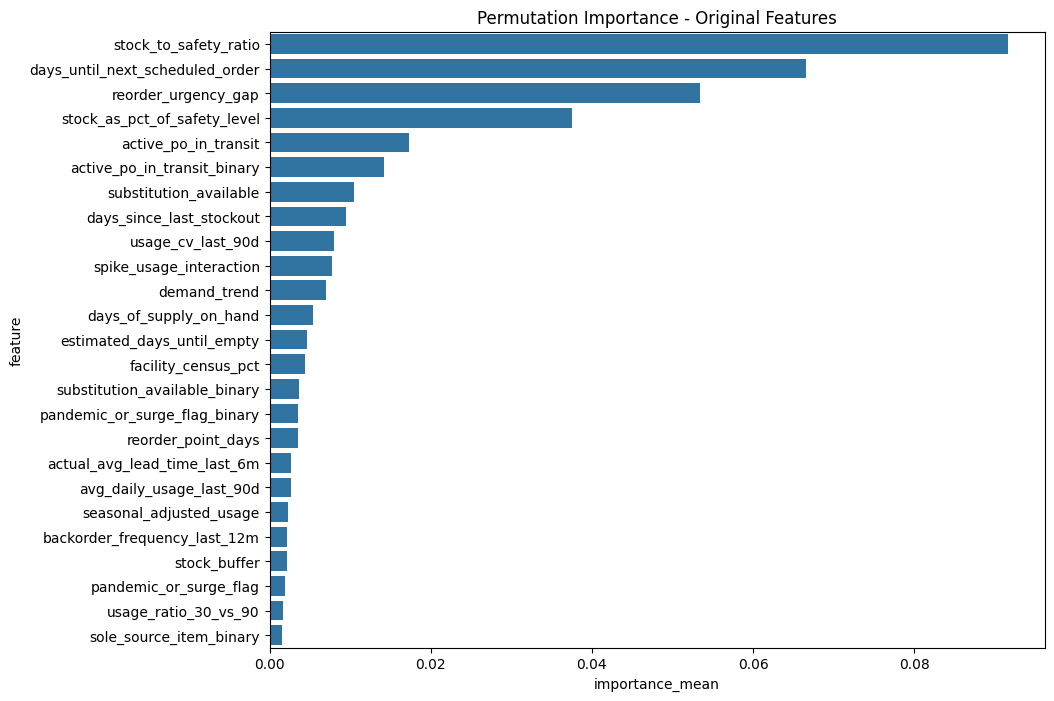

In [38]:
plt.figure(figsize=(10,8))
sns.barplot(data=perm_df.head(25), x='importance_mean', y='feature')
plt.title('Permutation Importance - Original Features')
plt.show()

# 11. SHAP Explainability Optional

SHAP gives detailed model explanations. This cell runs only if `shap` is installed.

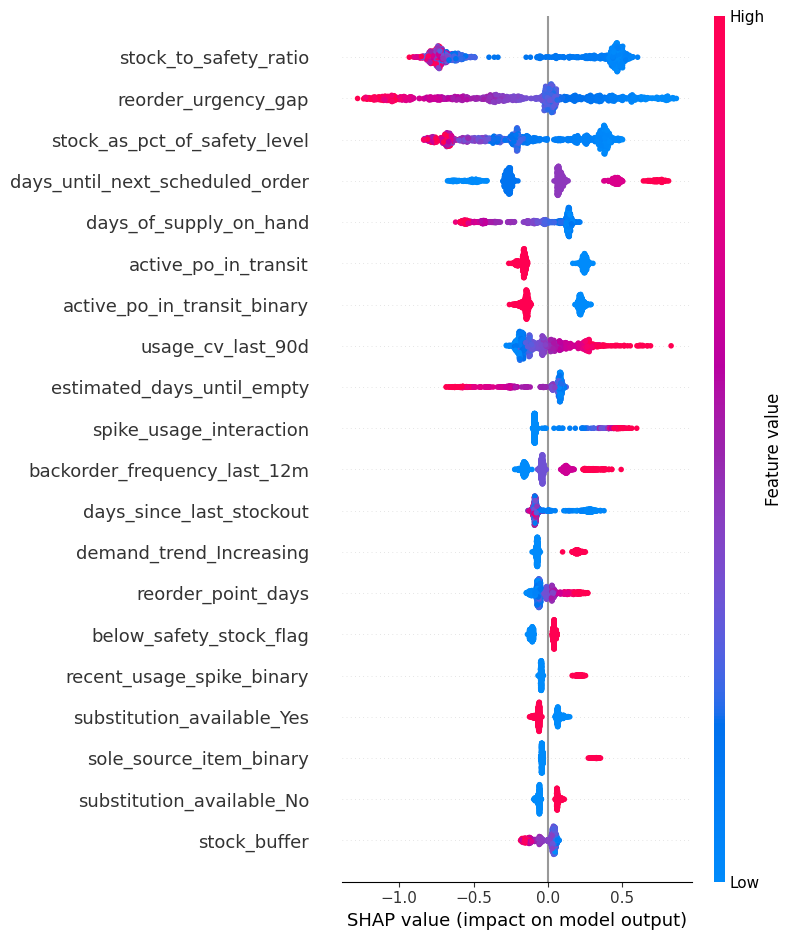

In [39]:
try:
    import shap
    shap_available = True
except Exception as e:
    shap_available = False
    print('SHAP not available:', e)

if shap_available:
    # Transform sample
    X_train_transformed = explain_pipeline.named_steps['preprocessor'].transform(X_train)
    X_test_transformed = explain_pipeline.named_steps['preprocessor'].transform(X_test_sample)

    model_for_shap = explain_pipeline.named_steps['model']

    try:
        explainer = shap.TreeExplainer(model_for_shap)
        shap_values = explainer.shap_values(X_test_transformed)
        shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=20)
    except Exception as e:
        print('Tree SHAP failed. Trying general explainer may be slower.')
        print(e)
else:
    print('Install SHAP using: pip install shap')

# 12. Time Series Analysis

Even though the main target is classification, the date column allows trend analysis and forecasting of stockout risk over time.

In [40]:
# Create daily stockout rate time series
if DATE_COL in df.columns:
    ts_daily = (
        df.assign(**{DATE_COL: pd.to_datetime(df[DATE_COL], errors='coerce')})
          .dropna(subset=[DATE_COL])
          .groupby(DATE_COL)
          .agg(
              stockout_rate=(TARGET, 'mean'),
              stockout_count=(TARGET, 'sum'),
              total_records=(TARGET, 'count')
          )
          .reset_index()
          .sort_values(DATE_COL)
    )

    ts_daily['stockout_rate_7d_ma'] = ts_daily['stockout_rate'].rolling(7, min_periods=1).mean()
    ts_daily['stockout_rate_30d_ma'] = ts_daily['stockout_rate'].rolling(30, min_periods=1).mean()

    display(ts_daily.head())
else:
    raise ValueError('snapshot_date column not available for time series analysis')

,snapshot_date,stockout_rate,stockout_count,total_records,stockout_rate_7d_ma,stockout_rate_30d_ma
0,2021-01-04,0.270270,20,74,0.270270,0.270270
1,2021-01-05,0.138889,10,72,0.204580,0.204580
2,2021-01-06,0.153846,14,91,0.187668,0.187668
3,2021-01-07,0.250000,18,72,0.203251,0.203251
4,2021-01-08,0.295455,26,88,0.221692,0.221692


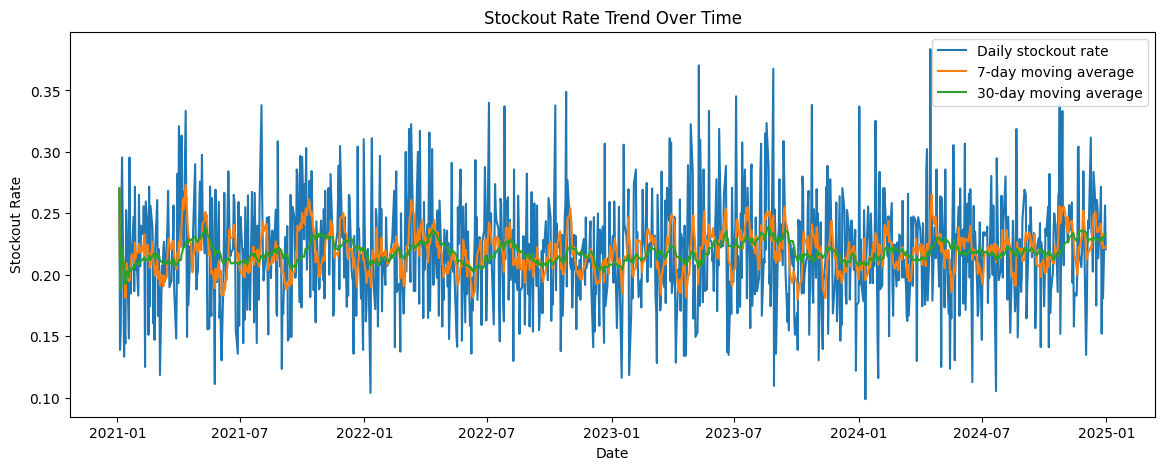

In [41]:
plt.figure(figsize=(14,5))
plt.plot(ts_daily[DATE_COL], ts_daily['stockout_rate'], label='Daily stockout rate')
plt.plot(ts_daily[DATE_COL], ts_daily['stockout_rate_7d_ma'], label='7-day moving average')
plt.plot(ts_daily[DATE_COL], ts_daily['stockout_rate_30d_ma'], label='30-day moving average')
plt.title('Stockout Rate Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Stockout Rate')
plt.legend()
plt.show()

In [42]:
# Weekly and monthly trends
ts_weekly = ts_daily.set_index(DATE_COL).resample('W').agg({
    'stockout_count': 'sum',
    'total_records': 'sum'
})
ts_weekly['stockout_rate'] = ts_weekly['stockout_count'] / ts_weekly['total_records']

ts_monthly = ts_daily.set_index(DATE_COL).resample('ME').agg({
    'stockout_count': 'sum',
    'total_records': 'sum'
})
ts_monthly['stockout_rate'] = ts_monthly['stockout_count'] / ts_monthly['total_records']

display(ts_weekly.head())
display(ts_monthly.head())

,stockout_count,total_records,stockout_rate
snapshot_date,,,
2021-01-10,88,397,0.221662
2021-01-17,83,458,0.181223
2021-01-24,90,437,0.205950
2021-01-31,93,412,0.225728
2021-02-07,87,393,0.221374


,stockout_count,total_records,stockout_rate
snapshot_date,,,
2021-01-31,354,1704,0.207746
2021-02-28,345,1624,0.212438
2021-03-31,423,1982,0.213421
2021-04-30,429,1857,0.231018
2021-05-31,407,1837,0.221557


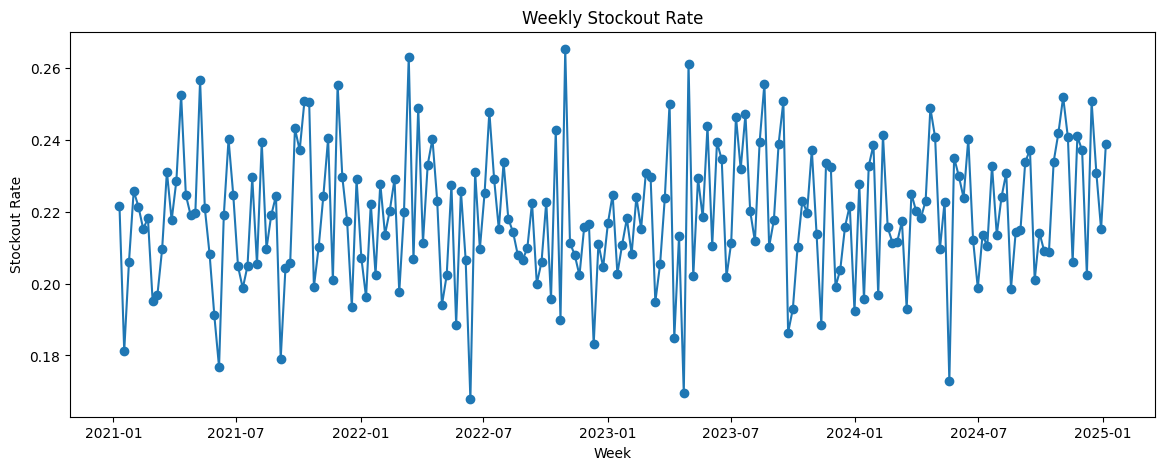

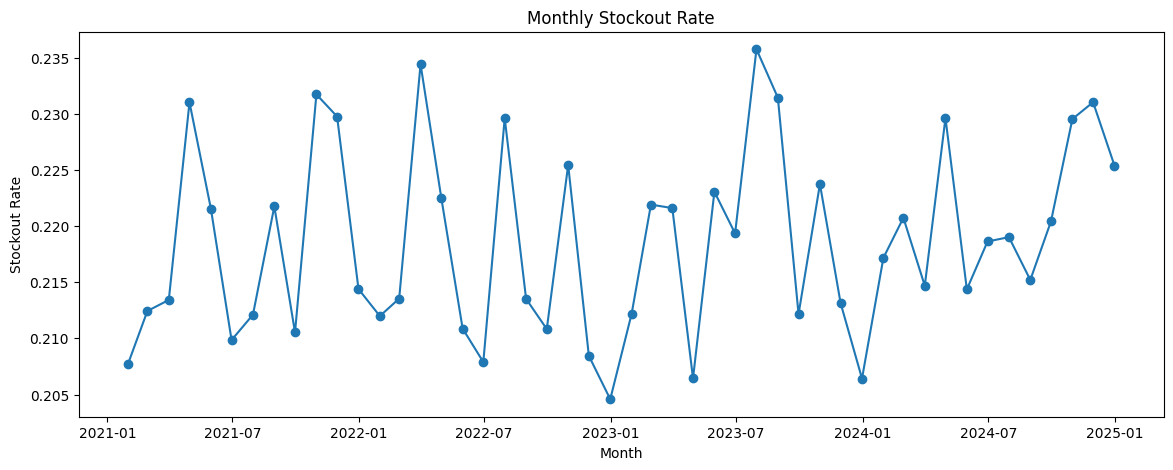

In [43]:
plt.figure(figsize=(14,5))
plt.plot(ts_weekly.index, ts_weekly['stockout_rate'], marker='o')
plt.title('Weekly Stockout Rate')
plt.xlabel('Week')
plt.ylabel('Stockout Rate')
plt.show()

plt.figure(figsize=(14,5))
plt.plot(ts_monthly.index, ts_monthly['stockout_rate'], marker='o')
plt.title('Monthly Stockout Rate')
plt.xlabel('Month')
plt.ylabel('Stockout Rate')
plt.show()

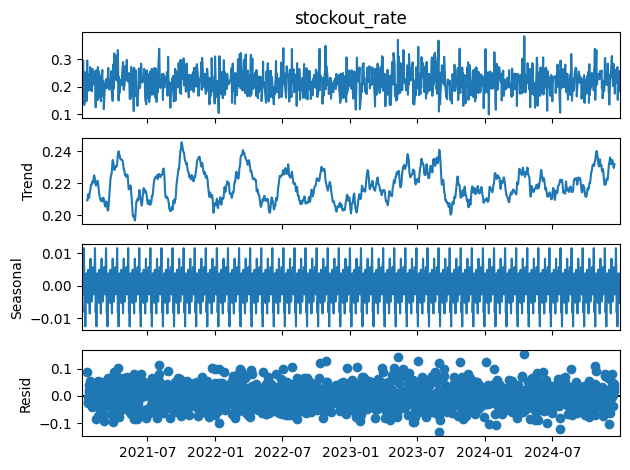

In [60]:
# Seasonal decomposition
try:
    from statsmodels.tsa.seasonal import seasonal_decompose

    series = ts_daily.set_index(DATE_COL)['stockout_rate'].asfreq('D')
    series = series.interpolate().bfill().ffill()

    if len(series) >= 60:
        decomposition = seasonal_decompose(series, model='additive', period=30)
        decomposition.plot()
        plt.show()
    else:
        print('Not enough daily data for seasonal decomposition with period=30.')
except Exception as e:
    print('Seasonal decomposition failed:', e)

# 13. Time Series Forecasting: ARIMA / SARIMA

Test Series Index: DatetimeIndex(['2024-03-15', '2024-03-16', '2024-03-17', '2024-03-18',
               '2024-03-19', '2024-03-20', '2024-03-21', '2024-03-22',
               '2024-03-23', '2024-03-24',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[us]', name='snapshot_date', length=292, freq='D')


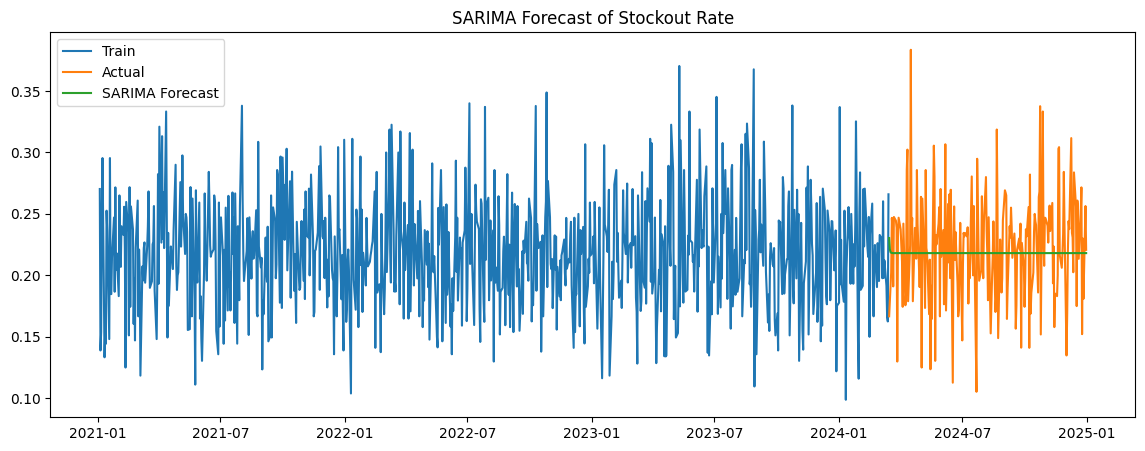

In [59]:
try:
    import matplotlib.pyplot as plt
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # Fix: Replaced deprecated fillna(method=...) with modern .bfill() and .ffill()
    series = ts_daily.set_index(DATE_COL)['stockout_rate'].asfreq('D')
    series = series.interpolate().bfill().ffill()

    if len(series) >= 40:
        train_size = int(len(series) * 0.8)
        train_series = series.iloc[:train_size]
        test_series = series.iloc[train_size:]
        print("Test Series Index:", test_series.index)

        sarima_model = SARIMAX(
            train_series,
            order=(1,1,1),
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_result = sarima_model.fit(disp=False)
        forecast = sarima_result.forecast(steps=len(test_series))

        plt.figure(figsize=(14,5))
        plt.plot(train_series.index, train_series, label='Train')
        plt.plot(test_series.index, test_series, label='Actual')
        plt.plot(test_series.index, forecast, label='SARIMA Forecast')
        plt.title('SARIMA Forecast of Stockout Rate')
        plt.legend()
        plt.show()
    else:
        print('Not enough data for SARIMA forecasting.')
except Exception as e:
    print('SARIMA failed:', e)

# 14. Time Series Forecasting: Prophet Optional

12:57:24 - cmdstanpy - INFO - Chain [1] start processing
12:57:25 - cmdstanpy - INFO - Chain [1] done processing


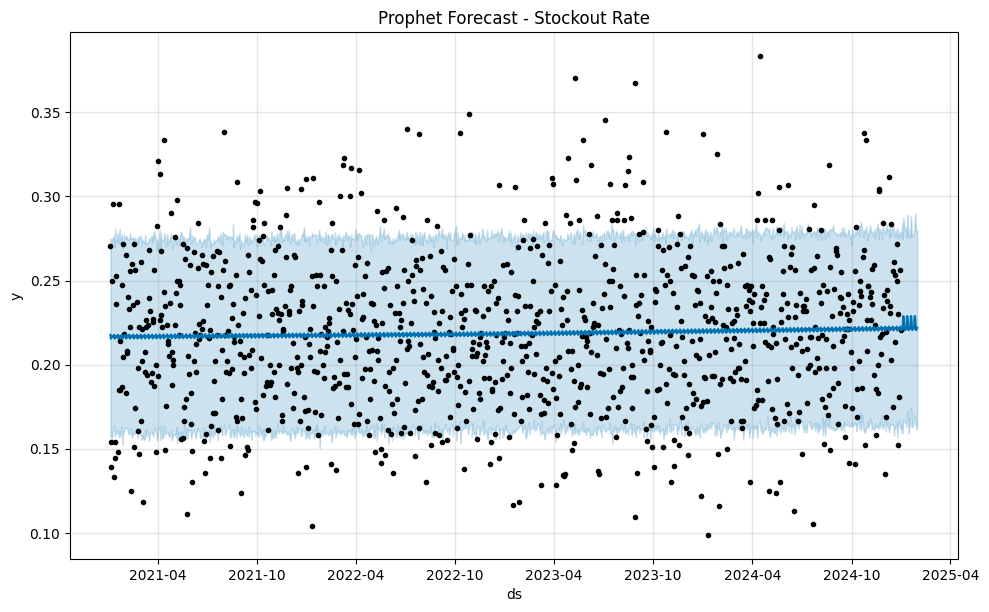

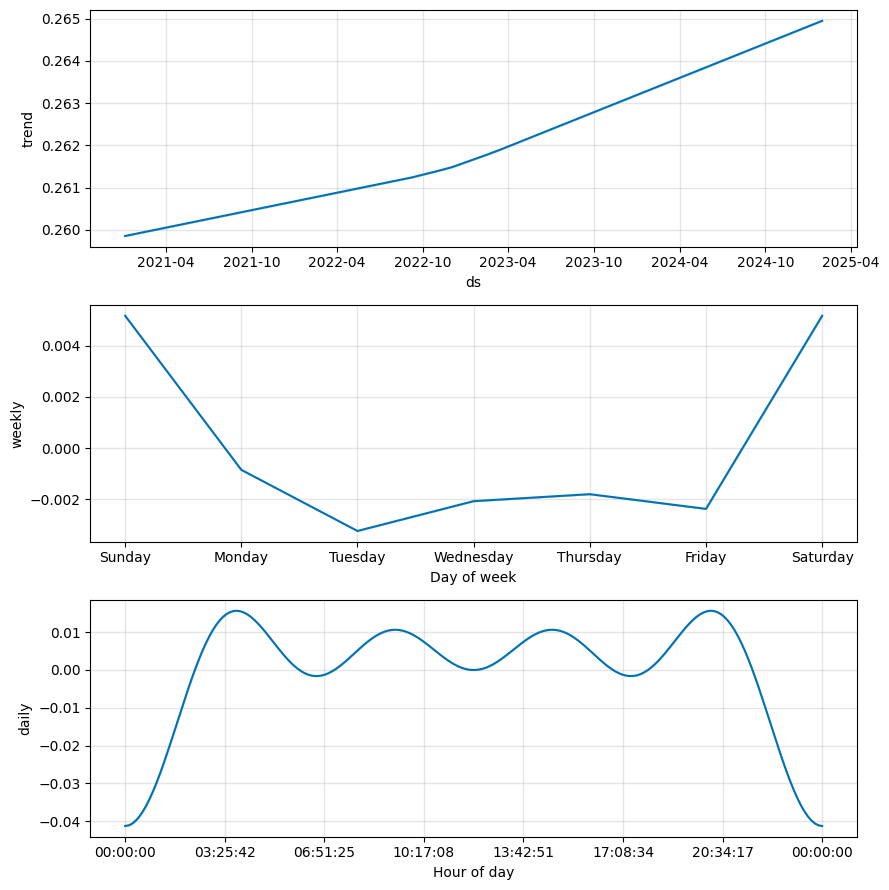

In [46]:
try:
    from prophet import Prophet
    prophet_available = True
except Exception as e:
    prophet_available = False
    print('Prophet not available:', e)

if prophet_available:
    prophet_df = ts_daily[[DATE_COL, 'stockout_rate']].rename(columns={DATE_COL: 'ds', 'stockout_rate': 'y'})
    prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    prophet_model.fit(prophet_df)

    future = prophet_model.make_future_dataframe(periods=30)
    forecast = prophet_model.predict(future)

    fig1 = prophet_model.plot(forecast)
    plt.title('Prophet Forecast - Stockout Rate')
    plt.show()

    fig2 = prophet_model.plot_components(forecast)
    plt.show()
else:
    print('Install Prophet using: pip install prophet')

# 15. Supervised ML Forecasting with Lag and Rolling Features

This creates forecasting features from historical stockout rates.

In [47]:
def create_ts_features(ts_data, date_col=DATE_COL, target_col='stockout_rate'):
    data = ts_data[[date_col, target_col]].copy().sort_values(date_col)
    data['dayofweek'] = data[date_col].dt.dayofweek
    data['month'] = data[date_col].dt.month
    data['quarter'] = data[date_col].dt.quarter

    for lag in [1, 2, 3, 7, 14, 30]:
        data[f'lag_{lag}'] = data[target_col].shift(lag)

    for window in [3, 7, 14, 30]:
        data[f'rolling_mean_{window}'] = data[target_col].shift(1).rolling(window).mean()
        data[f'rolling_std_{window}'] = data[target_col].shift(1).rolling(window).std()

    data = data.dropna()
    return data

ts_ml = create_ts_features(ts_daily)
print(ts_ml.shape)
ts_ml.head()

(1012, 19)


,snapshot_date,stockout_rate,dayofweek,month,quarter,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_3,rolling_std_3,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_30,rolling_std_30
30,2021-02-15,0.235294,0,2,1,0.259740,0.125000,0.222222,0.206897,0.186667,0.270270,0.202321,0.069540,0.220364,0.045877,0.219930,0.039414,0.212742,0.049734
31,2021-02-16,0.151163,1,2,1,0.235294,0.259740,0.125000,0.240000,0.271605,0.138889,0.206678,0.071784,0.224421,0.045743,0.223404,0.038387,0.211576,0.048739
32,2021-02-17,0.271739,2,2,1,0.151163,0.235294,0.259740,0.232877,0.204301,0.153846,0.215399,0.056957,0.211730,0.052522,0.214801,0.040206,0.211985,0.048155
33,2021-02-18,0.174419,3,2,1,0.271739,0.151163,0.235294,0.255814,0.217949,0.250000,0.219399,0.061840,0.217282,0.056993,0.219618,0.042807,0.215915,0.048058
34,2021-02-19,0.256098,4,2,1,0.174419,0.271739,0.151163,0.222222,0.183099,0.295455,0.199107,0.063967,0.205654,0.056118,0.216508,0.044486,0.213395,0.048190


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000317 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3564
[LightGBM] [Info] Number of data points in the train set: 809, number of used features: 17
[LightGBM] [Info] Start training from score 0.217760
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Model,MAE,RMSE,R2
0,RF Regressor,0.035647,0.045009,-0.040895
1,GB Regressor,0.036225,0.045057,-0.043108
3,LGBM Regressor,0.036690,0.046355,-0.104067
2,XGB Regressor,0.037742,0.047464,-0.157519


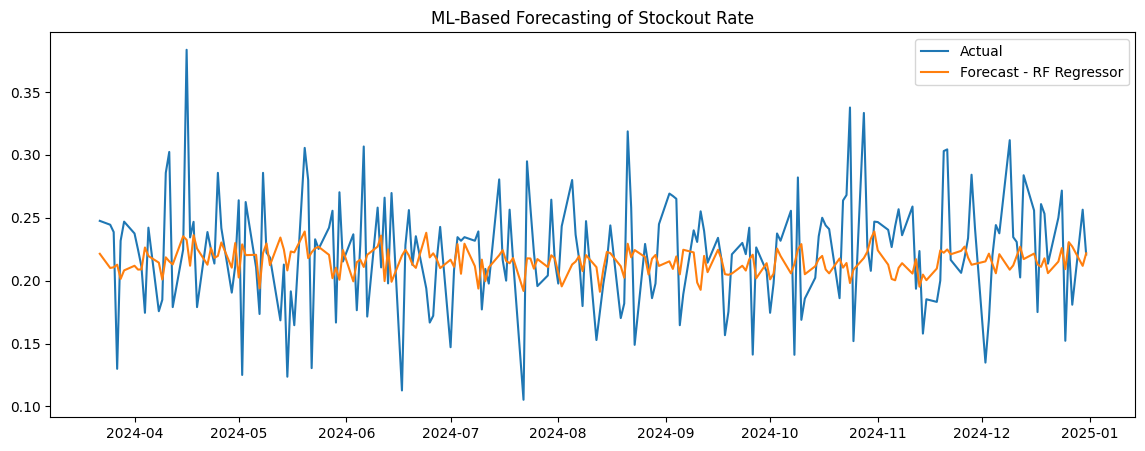

In [48]:
if len(ts_ml) > 20:
    forecast_features = [c for c in ts_ml.columns if c not in [DATE_COL, 'stockout_rate']]
    X_ts = ts_ml[forecast_features]
    y_ts = ts_ml['stockout_rate']

    split_idx = int(len(ts_ml) * 0.8)
    X_ts_train, X_ts_test = X_ts.iloc[:split_idx], X_ts.iloc[split_idx:]
    y_ts_train, y_ts_test = y_ts.iloc[:split_idx], y_ts.iloc[split_idx:]
    dates_ts_test = ts_ml[DATE_COL].iloc[split_idx:]

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

    ts_regressors = {
        'RF Regressor': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        'GB Regressor': GradientBoostingRegressor(random_state=RANDOM_STATE)
    }

    if optional_models_available.get('xgboost'):
        from xgboost import XGBRegressor
        ts_regressors['XGB Regressor'] = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1)

    if optional_models_available.get('lightgbm'):
        from lightgbm import LGBMRegressor
        ts_regressors['LGBM Regressor'] = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)

    ts_reg_results = []
    ts_reg_models = {}

    for name, reg in ts_regressors.items():
        reg.fit(X_ts_train, y_ts_train)
        pred = reg.predict(X_ts_test)
        ts_reg_models[name] = reg
        ts_reg_results.append({
            'Model': name,
            'MAE': mean_absolute_error(y_ts_test, pred),
            'RMSE': np.sqrt(mean_squared_error(y_ts_test, pred)),
            'R2': r2_score(y_ts_test, pred)
        })

    ts_reg_results_df = pd.DataFrame(ts_reg_results).sort_values('RMSE')
    display(ts_reg_results_df)

    best_ts_name = ts_reg_results_df.iloc[0]['Model']
    best_ts_model = ts_reg_models[best_ts_name]
    best_ts_pred = best_ts_model.predict(X_ts_test)

    plt.figure(figsize=(14,5))
    plt.plot(dates_ts_test, y_ts_test.values, label='Actual')
    plt.plot(dates_ts_test, best_ts_pred, label=f'Forecast - {best_ts_name}')
    plt.title('ML-Based Forecasting of Stockout Rate')
    plt.legend()
    plt.show()
else:
    print('Not enough time-series data for supervised forecasting.')

# 16. Time-Aware Classification Evaluation

This evaluates the best classifier using chronological split instead of random split.

In [49]:
if time_split_available:
    time_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', models[best_model_name])
    ])

    time_pipe.fit(X_train_time, y_train_time)
    time_result = evaluate_classifier('Time Split ' + best_model_name, time_pipe, X_test_time, y_test_time)
    print(time_result)

    y_time_pred = time_pipe.predict(X_test_time)
    print(classification_report(y_test_time, y_time_pred, zero_division=0))
else:
    print('Time-aware classification skipped.')

{'Model': 'Time Split CatBoost', 'Accuracy': 0.7575485464137389, 'Balanced_Accuracy': 0.7905834716760728, 'Precision': 0.47476740907809417, 'Recall': 0.8500757193336699, 'F1': 0.6092619392185239, 'ROC_AUC': 0.8704316839944832, 'PR_AUC': 0.6427766852391621}
              precision    recall  f1-score   support

           0       0.94      0.73      0.82     13856
           1       0.47      0.85      0.61      3962

    accuracy                           0.76     17818
   macro avg       0.71      0.79      0.72     17818
weighted avg       0.84      0.76      0.78     17818



# 17. Save Best Model for Production

In [50]:
# Choose final model: tuned model if it improved PR-AUC, otherwise original best model
original_best_score = final_results_df[final_results_df['Model'] == best_model_name]['PR_AUC'].iloc[0]
if tuned_result['PR_AUC'] >= original_best_score:
    final_model = tuned_best_pipeline
    final_model_name = 'Tuned ' + tuning_model_name
else:
    final_model = best_pipeline
    final_model_name = best_model_name

best_threshold = float(best_threshold_row['Threshold'])

os.makedirs('artifacts', exist_ok=True)
model_path = 'artifacts/best_stockout_prediction_model.pkl'
metadata_path = 'artifacts/model_metadata.pkl'

joblib.dump(final_model, model_path)
joblib.dump({
    'final_model_name': final_model_name,
    'best_threshold': best_threshold,
    'target': TARGET,
    'date_col': DATE_COL,
    'id_cols': ID_COLS,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'results': final_results_df
}, metadata_path)

print('Saved model:', model_path)
print('Saved metadata:', metadata_path)
print('Final model:', final_model_name)
print('Best threshold:', best_threshold)

Saved model: artifacts/best_stockout_prediction_model.pkl
Saved metadata: artifacts/model_metadata.pkl
Final model: CatBoost
Best threshold: 0.5800000000000002


# 18. Production Inference Function

Use this function to predict stockout risk for new records.

In [51]:
def predict_stockout_risk(new_data, model_path='artifacts/best_stockout_prediction_model.pkl', metadata_path='artifacts/model_metadata.pkl'):
    model = joblib.load(model_path)
    metadata = joblib.load(metadata_path)
    threshold = metadata['best_threshold']

    new_data_fe = create_features(new_data)

    # Drop target, ID, and date columns if present
    drop_cols_inference = [metadata['target']] + metadata['id_cols'] + [metadata['date_col']]
    X_new = new_data_fe.drop(columns=drop_cols_inference, errors='ignore')

    # Align columns to training columns
    # Missing columns will be created as NaN; extra columns will be removed.
    train_cols = X.columns.tolist()
    for col in train_cols:
        if col not in X_new.columns:
            X_new[col] = np.nan
    X_new = X_new[train_cols]

    probabilities = model.predict_proba(X_new)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    output = new_data.copy()
    output['stockout_probability'] = probabilities
    output['stockout_prediction'] = predictions
    output['risk_level'] = pd.cut(
        probabilities,
        bins=[-0.001, 0.30, 0.60, 1.00],
        labels=['Low', 'Medium', 'High']
    )
    return output

# Example:
# sample_predictions = predict_stockout_risk(df.head(10))
# sample_predictions[[TARGET, 'stockout_probability', 'stockout_prediction', 'risk_level']]

# 19. Final Project Summary

Use the generated leaderboard to answer:

1. Which model has the best accuracy?
2. Which model has the best recall?
3. Which model has the best F1 score?
4. Which model has the best PR-AUC?
5. Which model is best for production?

For stockout prediction, the production model should usually be selected using **Recall**, **F1**, or **PR-AUC**, not accuracy alone.

Recommended final choice:

- If business priority is catching maximum stockouts: choose highest **Recall**.
- If business priority is balanced performance: choose highest **F1**.
- If the dataset is imbalanced: choose highest **PR-AUC**.
- If your evaluator strictly asks for accuracy: choose highest **Accuracy**.

Test Series Index: DatetimeIndex(['2024-03-15', '2024-03-16', '2024-03-17', '2024-03-18',
               '2024-03-19', '2024-03-20', '2024-03-21', '2024-03-22',
               '2024-03-23', '2024-03-24',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[us]', name='snapshot_date', length=292, freq='D')


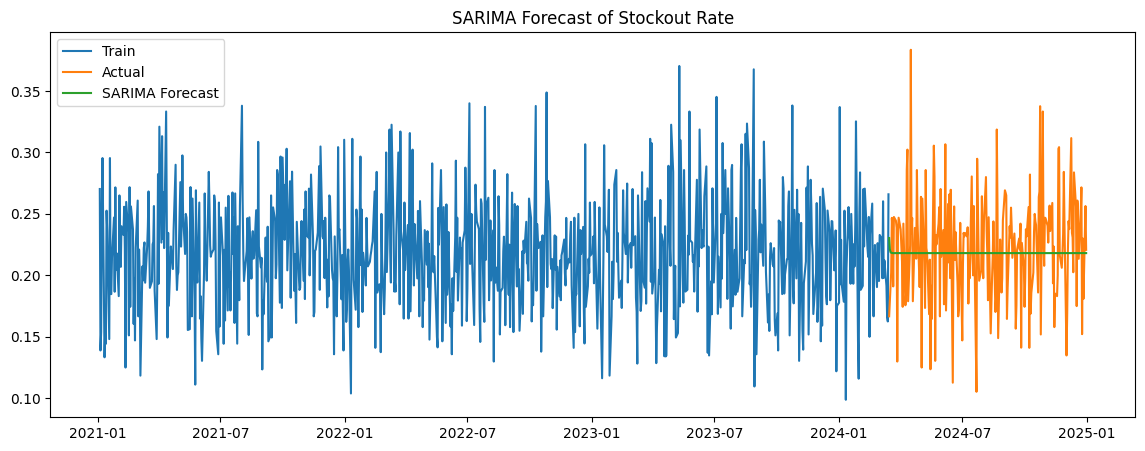

In [58]:
try:
    import matplotlib.pyplot as plt
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # Fix: Replaced deprecated fillna(method=...) with modern .bfill() and .ffill()
    series = ts_daily.set_index(DATE_COL)['stockout_rate'].asfreq('D')
    series = series.interpolate().bfill().ffill()

    if len(series) >= 40:
        train_size = int(len(series) * 0.8)
        train_series = series.iloc[:train_size]
        test_series = series.iloc[train_size:]
        print("Test Series Index:", test_series.index)

        sarima_model = SARIMAX(
            train_series,
            order=(1,1,1),
            seasonal_order=(1,0,1,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        sarima_result = sarima_model.fit(disp=False)
        forecast = sarima_result.forecast(steps=len(test_series))

        plt.figure(figsize=(14,5))
        plt.plot(train_series.index, train_series, label='Train')
        plt.plot(test_series.index, test_series, label='Actual')
        plt.plot(test_series.index, forecast, label='SARIMA Forecast')
        plt.title('SARIMA Forecast of Stockout Rate')
        plt.legend()
        plt.show()
    else:
        print('Not enough data for SARIMA forecasting.')
except Exception as e:
    print('SARIMA failed:', e)
